# Imports 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Device 

In [2]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


# Load the data 

In [3]:



data = np.load("10_DATA_TRPCAGE.npy")

print("Data shape:", data.shape)

Data shape: (50000, 38)


# Normalization 

In [51]:

# Not needed here as data is already normalized 

data_mean = data.mean(axis=0)
data_std  = data.std(axis=0) + 1e-8

data_norm = (data - data_mean) / data_std

# Convert and load the data into tensors

In [52]:


tensor_data = torch.tensor(data_norm, dtype=torch.float32)

dataset = TensorDataset(tensor_data)

loader = DataLoader(
    dataset,
    batch_size=1024,
    shuffle=True
)



# HYPERPARAMETERS


In [40]:
input_dim  = data.shape[1]
latent_dim = 4

epochs = 200
lr = 5e-3

# Variational Auto Encoder 

In [41]:
class VAE(nn.Module):

    def __init__(self, input_dim, latent_dim):

        super().__init__()

        # ====================================================
        # ENCODER
        # ====================================================

        self.encoder = nn.Sequential(

            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU()

        )

        # ====================================================
        # LATENT PARAMETERS
        # ====================================================

        self.mu = nn.Linear(16, latent_dim)

        self.logvar = nn.Linear(16, latent_dim)

        # ====================================================
        # DECODER
        # ====================================================

        self.decoder = nn.Sequential(

            nn.Linear(latent_dim, 16),
            nn.ReLU(),

            nn.Linear(16, 32),
            nn.ReLU(),

            nn.Linear(32, input_dim)

        )

    # ========================================================
    # REPARAMETERIZATION
    # ========================================================

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        h = self.encoder(x)

        mu = self.mu(h)

        logvar = self.logvar(h)

        z = self.reparameterize(mu, logvar)

        xhat = self.decoder(z)

        return xhat, mu, logvar, z


# Initialize the model and optimizer 

In [42]:
VAE_model = VAE(input_dim, latent_dim).to(device)

optimizer_vae = torch.optim.Adam(VAE_model.parameters(), lr=lr)



# VAE LOSS


In [43]:


def vae_loss(x, xhat, mu, logvar):

    # ========================================================
    # RECONSTRUCTION LOSS
    # ========================================================

    recon_loss = nn.functional.mse_loss(
        xhat,
        x,
        reduction='mean'
    )

    # ========================================================
    # KL DIVERGENCE
    # ========================================================

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - torch.exp(logvar)
    )

    total_loss = recon_loss + kl_loss

    return total_loss, recon_loss, kl_loss

# Training 

In [53]:
# ============================================================
# TRAIN VAE
# ============================================================

vae_total_losses = []
vae_recon_losses = []
vae_kl_losses = []

print("\nTraining VAE...\n")

for epoch in range(epochs):

    total_epoch = 0.0
    recon_epoch = 0.0
    kl_epoch = 0.0

    for batch in loader:

        x = batch[0].to(device)

        xhat, mu, logvar, z = VAE_model(x)

        loss, recon, kl = vae_loss(
            x,
            xhat,
            mu,
            logvar
        )

        optimizer_vae.zero_grad()

        loss.backward()

        optimizer_vae.step()

        total_epoch += loss.item()
        recon_epoch += recon.item()
        kl_epoch += kl.item()

    avg_total = total_epoch / len(loader)
    avg_recon = recon_epoch / len(loader)
    avg_kl = kl_epoch / len(loader)

    vae_total_losses.append(avg_total)
    vae_recon_losses.append(avg_recon)
    vae_kl_losses.append(avg_kl)

    print(
        f"VAE Epoch [{epoch+1}/{epochs}] "
        f"Total: {avg_total:.6f} "
        f"Recon: {avg_recon:.6f} "
        f"KL: {avg_kl:.6f}"
    )



Training VAE...

VAE Epoch [1/200] Total: 1.154326 Recon: 1.138288 KL: 0.016038
VAE Epoch [2/200] Total: 1.000676 Recon: 1.000449 KL: 0.000227
VAE Epoch [3/200] Total: 1.000293 Recon: 1.000200 KL: 0.000093
VAE Epoch [4/200] Total: 1.000315 Recon: 1.000256 KL: 0.000059
VAE Epoch [5/200] Total: 1.000326 Recon: 1.000283 KL: 0.000043
VAE Epoch [6/200] Total: 1.000160 Recon: 1.000127 KL: 0.000034
VAE Epoch [7/200] Total: 1.000197 Recon: 1.000170 KL: 0.000027
VAE Epoch [8/200] Total: 1.000103 Recon: 1.000080 KL: 0.000024
VAE Epoch [9/200] Total: 1.000161 Recon: 1.000143 KL: 0.000018
VAE Epoch [10/200] Total: 1.000048 Recon: 1.000032 KL: 0.000016
VAE Epoch [11/200] Total: 1.000147 Recon: 1.000134 KL: 0.000013
VAE Epoch [12/200] Total: 1.000069 Recon: 1.000058 KL: 0.000012
VAE Epoch [13/200] Total: 1.000075 Recon: 1.000064 KL: 0.000011
VAE Epoch [14/200] Total: 1.000204 Recon: 1.000195 KL: 0.000009
VAE Epoch [15/200] Total: 1.000125 Recon: 1.000116 KL: 0.000008
VAE Epoch [16/200] Total: 1.000

VAE Epoch [130/200] Total: 1.000116 Recon: 1.000116 KL: 0.000001
VAE Epoch [131/200] Total: 1.000004 Recon: 1.000001 KL: 0.000002
VAE Epoch [132/200] Total: 1.000164 Recon: 1.000163 KL: 0.000001
VAE Epoch [133/200] Total: 1.000115 Recon: 1.000114 KL: 0.000001
VAE Epoch [134/200] Total: 1.000073 Recon: 1.000073 KL: 0.000001
VAE Epoch [135/200] Total: 1.000178 Recon: 1.000177 KL: 0.000000
VAE Epoch [136/200] Total: 1.000143 Recon: 1.000142 KL: 0.000001
VAE Epoch [137/200] Total: 1.000048 Recon: 1.000047 KL: 0.000001
VAE Epoch [138/200] Total: 1.000059 Recon: 1.000059 KL: 0.000000
VAE Epoch [139/200] Total: 1.000062 Recon: 1.000060 KL: 0.000001
VAE Epoch [140/200] Total: 1.000035 Recon: 1.000034 KL: 0.000001
VAE Epoch [141/200] Total: 1.000062 Recon: 1.000061 KL: 0.000001
VAE Epoch [142/200] Total: 1.000087 Recon: 1.000087 KL: 0.000000
VAE Epoch [143/200] Total: 1.000216 Recon: 1.000216 KL: 0.000000
VAE Epoch [144/200] Total: 1.000031 Recon: 1.000031 KL: 0.000000
VAE Epoch [145/200] Total

# VAE LOSSES


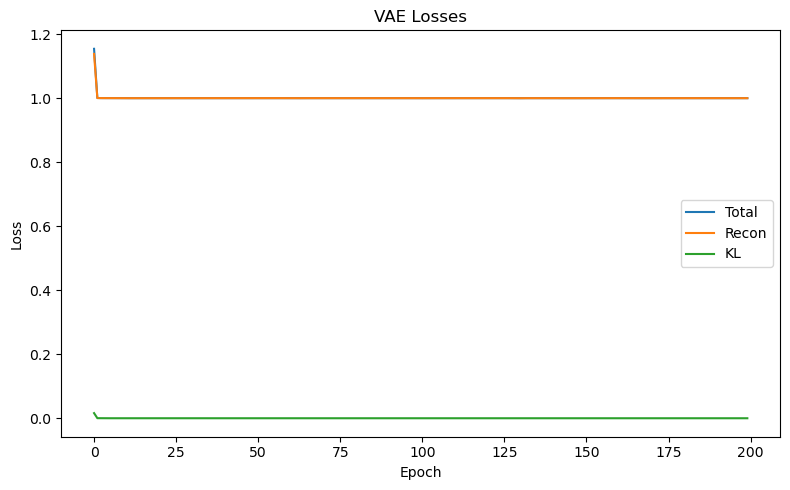

In [54]:


plt.figure(figsize=(8,5))

plt.plot(vae_total_losses, label="Total")

plt.plot(vae_recon_losses, label="Recon")

plt.plot(vae_kl_losses, label="KL")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("VAE Losses")

plt.legend()

plt.tight_layout()

plt.savefig("vae_losses.png", dpi=300)

# Save the MOdel 

In [46]:

# ============================================================
# SAVE VAE
# ============================================================

torch.save(VAE_model.state_dict(), "vae.pt")

print("\nVAE saved.")


VAE saved.


In [55]:
# ============================================================
# LATENT REPRESENTATION OF VAE
# ============================================================

VAE_model.eval()

latent_vae = []

with torch.no_grad():

    for batch in loader:

        x = batch[0].to(device)

        _, mu, _, _ = VAE_model(x)

        latent_vae.append(mu.cpu().numpy())

latent_vae = np.concatenate(latent_vae, axis=0)

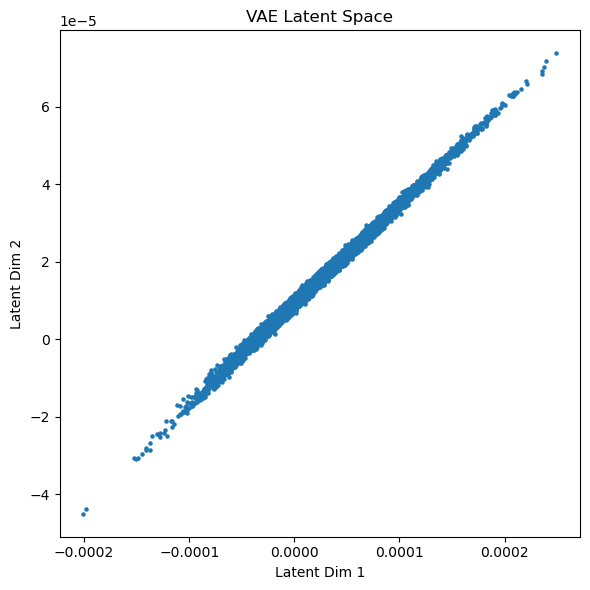

In [56]:
# ============================================================
# PLOT VAE LATENT SPACE
# ============================================================

plt.figure(figsize=(6,6))

plt.scatter(
    latent_vae[:,0],
    latent_vae[:,1],
    s=5
)

plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")

plt.title("VAE Latent Space")

plt.tight_layout()

plt.savefig("vae_latent.png", dpi=300)

In [49]:

# ============================================================
# GENERATE NEW SAMPLES FROM VAE
# ============================================================

with torch.no_grad():

    z = torch.randn(1000, latent_dim).to(device)

    generated = VAE_model.decoder(z).cpu().numpy()

np.save("vae_generated.npy", generated)

print("Generated samples shape:", generated.shape)



Generated samples shape: (1000, 38)


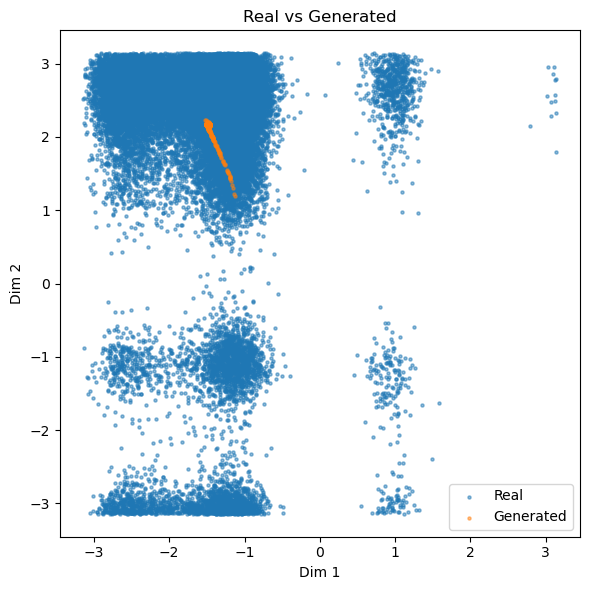


All plots saved.


In [50]:
# ============================================================
# COMPARE REAL VS GENERATED
# ============================================================

plt.figure(figsize=(6,6))

plt.scatter(
    data[:,0],
    data[:,1],
    s=5,
    alpha=0.5,
    label="Real"
)

plt.scatter(
    generated[:,0],
    generated[:,1],
    s=5,
    alpha=0.5,
    label="Generated"
)

plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.title("Real vs Generated")

plt.legend()

plt.tight_layout()

plt.savefig("real_vs_generated.png", dpi=300)

plt.show()

print("\nAll plots saved.")

# Posterior collapse 

In [57]:
print(mu.mean())
print(mu.std())

tensor(7.7099e-06)
tensor(5.1420e-05)


In [58]:
beta = 0.001

In [59]:


def vae_loss(x, xhat, mu, logvar):

    # ========================================================
    # RECONSTRUCTION LOSS
    # ========================================================

    recon_loss = nn.functional.mse_loss(
        xhat,
        x,
        reduction='mean'
    )

    # ========================================================
    # KL DIVERGENCE
    # ========================================================

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - torch.exp(logvar)
    )

    total_loss = recon_loss + beta*kl_loss

    return total_loss, recon_loss, kl_loss

In [60]:
# ============================================================
# TRAIN beta - VAE
# ============================================================

vae_total_losses = []
vae_recon_losses = []
vae_kl_losses = []

print("\nTraining VAE...\n")

for epoch in range(epochs):

    total_epoch = 0.0
    recon_epoch = 0.0
    kl_epoch = 0.0

    for batch in loader:

        x = batch[0].to(device)

        xhat, mu, logvar, z = VAE_model(x)

        loss, recon, kl = vae_loss(
            x,
            xhat,
            mu,
            logvar
        )

        optimizer_vae.zero_grad()

        loss.backward()

        optimizer_vae.step()

        total_epoch += loss.item()
        recon_epoch += recon.item()
        kl_epoch += kl.item()

    avg_total = total_epoch / len(loader)
    avg_recon = recon_epoch / len(loader)
    avg_kl = kl_epoch / len(loader)

    vae_total_losses.append(avg_total)
    vae_recon_losses.append(avg_recon)
    vae_kl_losses.append(avg_kl)

    print(
        f"VAE Epoch [{epoch+1}/{epochs}] "
        f"Total: {avg_total:.6f} "
        f"Recon: {avg_recon:.6f} "
        f"KL: {avg_kl:.6f}"
    )



Training VAE...

VAE Epoch [1/200] Total: 1.000036 Recon: 1.000036 KL: 0.000000
VAE Epoch [2/200] Total: 0.999992 Recon: 0.999992 KL: 0.000000
VAE Epoch [3/200] Total: 1.000124 Recon: 1.000124 KL: 0.000000
VAE Epoch [4/200] Total: 1.000105 Recon: 1.000105 KL: 0.000000
VAE Epoch [5/200] Total: 1.000069 Recon: 1.000069 KL: 0.000000
VAE Epoch [6/200] Total: 1.000071 Recon: 1.000071 KL: 0.000000
VAE Epoch [7/200] Total: 1.000078 Recon: 1.000078 KL: 0.000000
VAE Epoch [8/200] Total: 1.000148 Recon: 1.000148 KL: 0.000000
VAE Epoch [9/200] Total: 1.000119 Recon: 1.000119 KL: 0.000000
VAE Epoch [10/200] Total: 1.000088 Recon: 1.000088 KL: 0.000000
VAE Epoch [11/200] Total: 1.000049 Recon: 1.000049 KL: 0.000000
VAE Epoch [12/200] Total: 1.000174 Recon: 1.000174 KL: 0.000000
VAE Epoch [13/200] Total: 1.000163 Recon: 1.000163 KL: 0.000000
VAE Epoch [14/200] Total: 1.000095 Recon: 1.000095 KL: 0.000000
VAE Epoch [15/200] Total: 1.000146 Recon: 1.000146 KL: 0.000000
VAE Epoch [16/200] Total: 0.999

VAE Epoch [130/200] Total: 1.000026 Recon: 1.000026 KL: 0.000000
VAE Epoch [131/200] Total: 0.999971 Recon: 0.999971 KL: 0.000000
VAE Epoch [132/200] Total: 1.000053 Recon: 1.000053 KL: 0.000000
VAE Epoch [133/200] Total: 1.000083 Recon: 1.000083 KL: 0.000000
VAE Epoch [134/200] Total: 1.000118 Recon: 1.000118 KL: 0.000000
VAE Epoch [135/200] Total: 1.000015 Recon: 1.000015 KL: 0.000000
VAE Epoch [136/200] Total: 1.000119 Recon: 1.000119 KL: 0.000000
VAE Epoch [137/200] Total: 1.000188 Recon: 1.000188 KL: 0.000000
VAE Epoch [138/200] Total: 1.000185 Recon: 1.000185 KL: 0.000000
VAE Epoch [139/200] Total: 1.000017 Recon: 1.000017 KL: 0.000000
VAE Epoch [140/200] Total: 1.000060 Recon: 1.000060 KL: 0.000000
VAE Epoch [141/200] Total: 1.000110 Recon: 1.000110 KL: 0.000000
VAE Epoch [142/200] Total: 1.000065 Recon: 1.000065 KL: 0.000000
VAE Epoch [143/200] Total: 1.000072 Recon: 1.000072 KL: 0.000000
VAE Epoch [144/200] Total: 1.000139 Recon: 1.000139 KL: 0.000000
VAE Epoch [145/200] Total

In [61]:

# ============================================================
# SAVE VAE
# ============================================================

torch.save(VAE_model.state_dict(), "beta_vae.pt")

print("\n beta VAE saved.")


 beta VAE saved.


In [62]:
# ============================================================
# LATENT REPRESENTATION OF VAE
# ============================================================

VAE_model.eval()

latent_vae = []

with torch.no_grad():

    for batch in loader:

        x = batch[0].to(device)

        _, mu, _, _ = VAE_model(x)

        latent_vae.append(mu.cpu().numpy())

latent_vae = np.concatenate(latent_vae, axis=0)

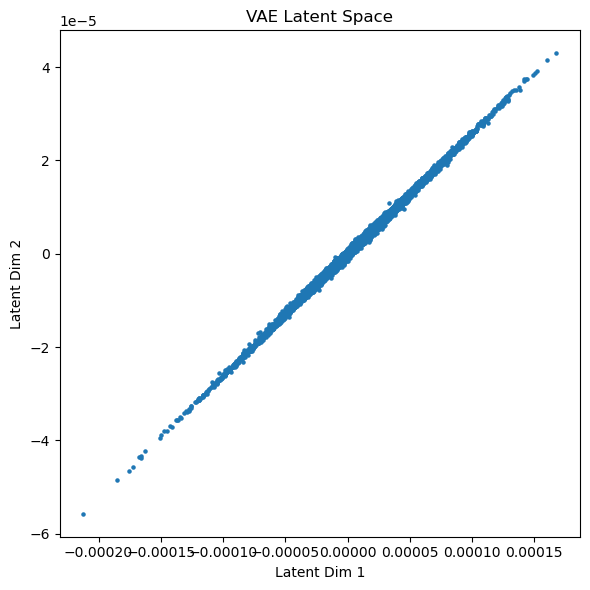

In [63]:
# ============================================================
# PLOT VAE LATENT SPACE
# ============================================================

plt.figure(figsize=(6,6))

plt.scatter(
    latent_vae[:,0],
    latent_vae[:,1],
    s=5
)

plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")

plt.title("VAE Latent Space")

plt.tight_layout()

plt.savefig("vae_latent.png", dpi=300)

In [64]:

# ============================================================
# GENERATE NEW SAMPLES FROM VAE
# ============================================================

with torch.no_grad():

    z = torch.randn(1000, latent_dim).to(device)

    generated = VAE_model.decoder(z).cpu().numpy()

np.save("vae_generated.npy", generated)

print("Generated samples shape:", generated.shape)



Generated samples shape: (1000, 38)


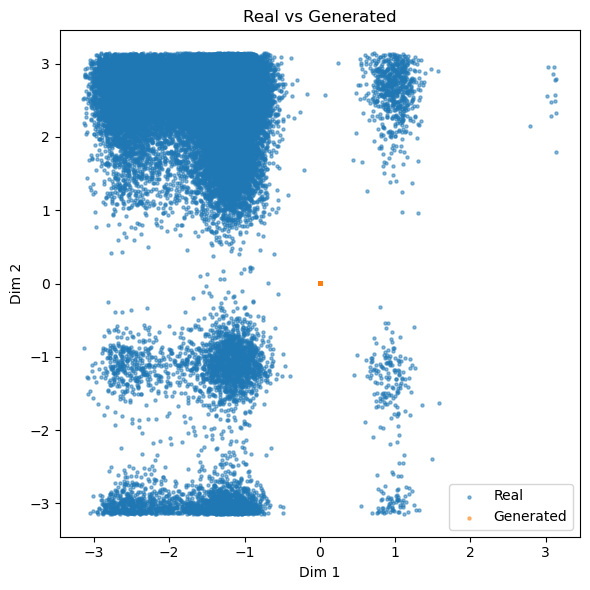


All plots saved.


In [65]:
# ============================================================
# COMPARE REAL VS GENERATED
# ============================================================

plt.figure(figsize=(6,6))

plt.scatter(
    data[:,0],
    data[:,1],
    s=5,
    alpha=0.5,
    label="Real"
)

plt.scatter(
    generated[:,0],
    generated[:,1],
    s=5,
    alpha=0.5,
    label="Generated"
)

plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.title("Real vs Generated")

plt.legend()

plt.tight_layout()

plt.savefig("real_vs_generated.png", dpi=300)

plt.show()

print("\nAll plots saved.")